In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
#Clone yolo-v5 model from github repo
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 17851 (delta 31), reused 8 (delta 8), pack-reused 17799 (from 3)
Receiving objects: 100% (17851/17851), 16.98 MiB | 24.28 MiB/s, done.
Resolving deltas: 100% (12161/12161), done.


In [4]:
%cd yolov5/
#Import required dependencies for the model
!pip install -r requirements.txt

##In the context of the YOLOv5 model, the requirement.txt file is used to specify the dependencies
#and versions of software libraries that are necessary for running the model successfully.
#When you install the requirements from the requirement.txt file,
#it ensures that all the required packages and their specific versions are installed in your environment.

/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [5]:
### Spliting Data into training and validation

import os
from random import choice
import shutil

#arrays to store file names
imgs =[]
xmls =[]

#setup dir names
# trainPath = '/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/images/train'
# valPath = '/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/images/val'
crsPath = '/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/data' #dir where images and annotations stored

#setup ratio (val ratio = rest of the files in origin dir after splitting into train and test)
train_ratio = 0.8
val_ratio = 0.2


#total count of imgs
totalImgCount = len(os.listdir(crsPath))/2

#soring files to corresponding arrays
for (dirname, dirs, files) in os.walk(crsPath):
    for filename in files:
        if filename.endswith('.txt'):
            xmls.append(filename)
        else:
            imgs.append(filename)


#counting range for cycles
countForTrain = int(len(imgs)*train_ratio)
countForVal = int(len(imgs)*val_ratio)
print("training images are : ",countForTrain)
print("Validation images are : ",countForVal)

FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/data'

In [ ]:
trainimagePath = '/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/images/train'
trainlabelPath = '/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/val/train'
valimagePath = '/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/images/val'
vallabelPath = '/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/val/val'
#cycle for train dir
for x in range(countForTrain):

    fileJpg = choice(imgs) # get name of random image from origin dir
    fileXml = fileJpg[:-4] +'.txt' # get name of corresponding annotation file

    #move both files into train dir
    shutil.copy(os.path.join(crsPath, fileJpg), os.path.join(trainimagePath, fileJpg))
    shutil.copy(os.path.join(crsPath, fileXml), os.path.join(trainlabelPath, fileXml))


    #remove files from arrays
    imgs.remove(fileJpg)
    xmls.remove(fileXml)

#cycle for val dir
for x in range(countForVal):

    fileJpg = choice(imgs) # get name of random image from origin dir
    fileXml = fileJpg[:-4] +'.txt' # get name of corresponding annotation file

    #move both files into train dir
    shutil.copy(os.path.join(crsPath, fileJpg), os.path.join(valimagePath, fileJpg))
    shutil.copy(os.path.join(crsPath, fileXml), os.path.join(vallabelPath, fileXml))

    #remove files from arrays
    imgs.remove(fileJpg)
    xmls.remove(fileXml)

#rest of files will be validation files, so rename origin dir to val dir
#os.rename(crsPath, valPath)
shutil.move(crsPath, valPath)

In [ ]:
## Resize the image into 320x320

import PIL
import os
import os.path
from PIL import Image

f = r'/content/gdrive/MyDrive/Colab Notebooks/YoLo Model/image_dataset/images/train'
for file in os.listdir(f):
    f_img = f+"/"+file
    img = Image.open(f_img)
    img = img.resize((320,320))
    img.save(f_img)

In [ ]:
!python train.py --img 320 --batch 16 --epochs 70 --data /content/yolov5/custom_data.yaml --weights yolov5s.pt --cache

train: weights=yolov5s.pt, cfg=, data=/content/yolov5/custom_data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=70, batch_size=16, imgsz=320, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v7.0-192-g459dd49 Python-3.10.12 torch-2.0.1+cu118 CPU

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0, fl_gamma=0.0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, degr

[Errno 2] No such file or directory: 'yolov5/'
/content/yolov5


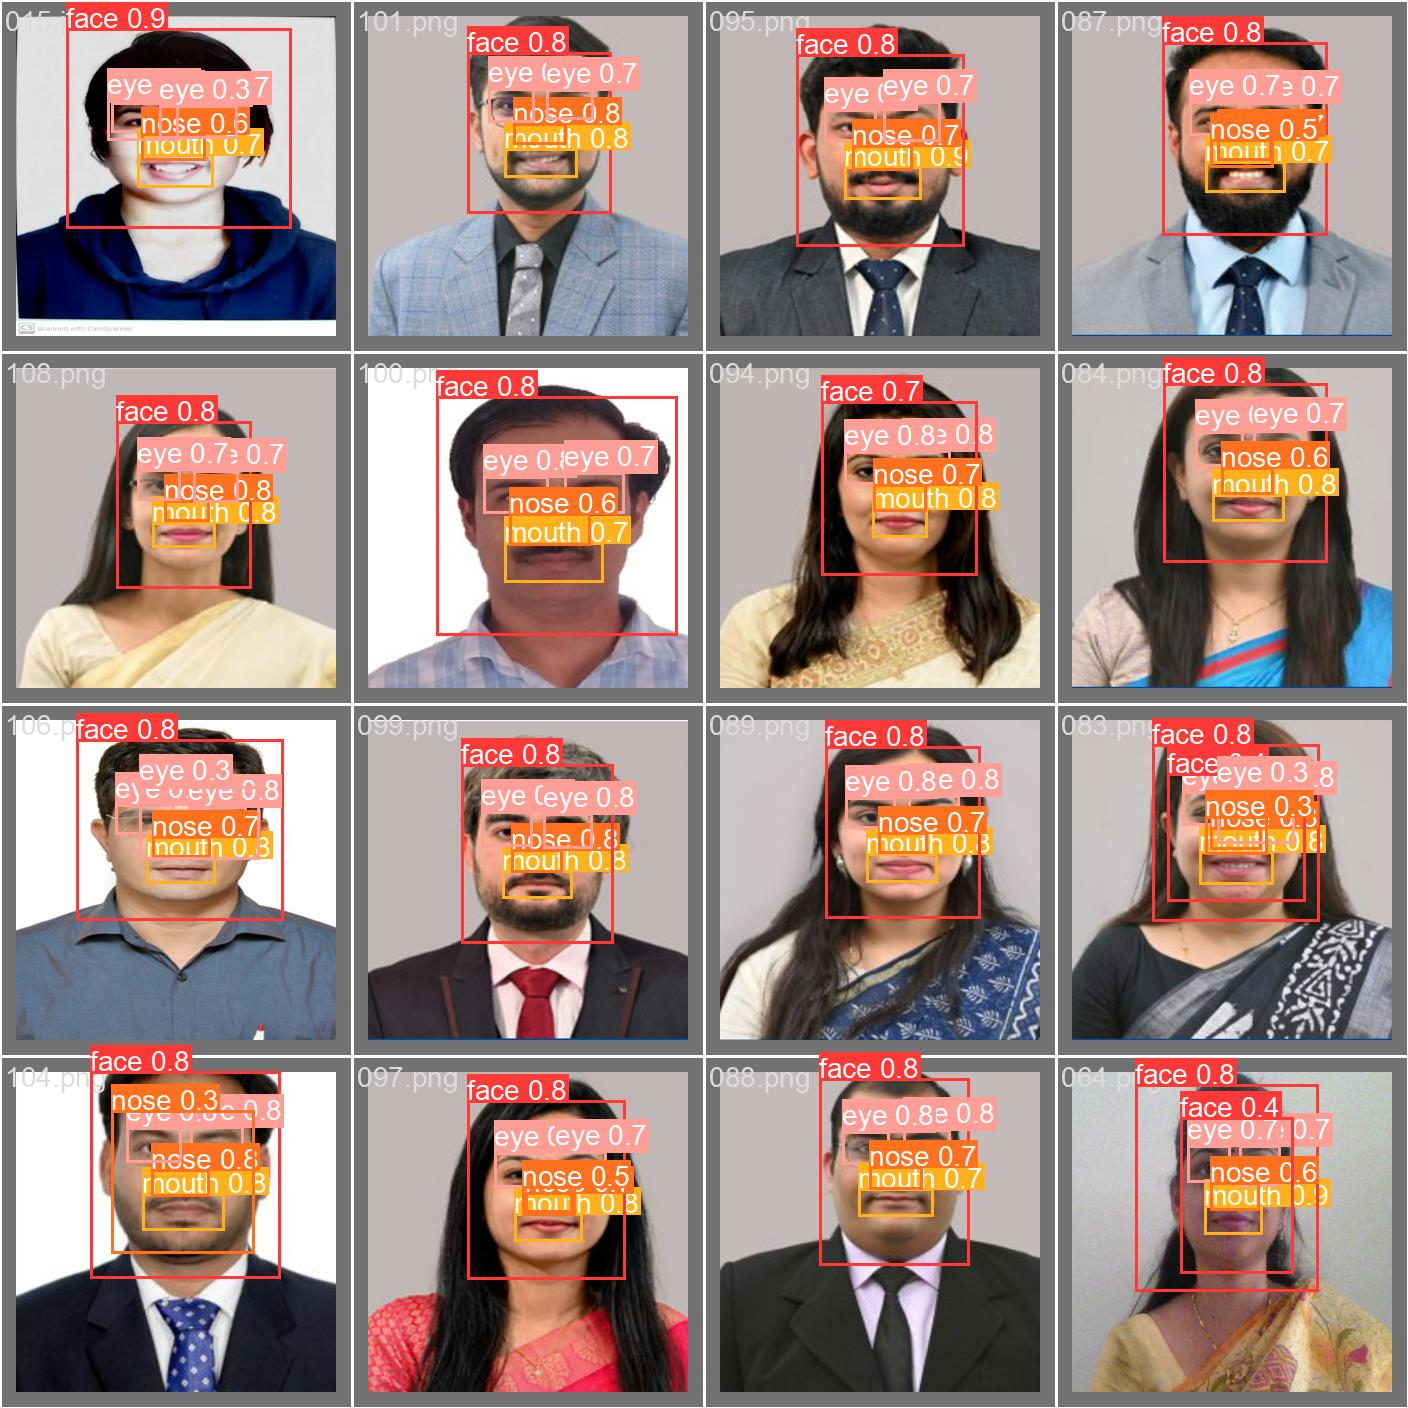

In [ ]:
%cd yolov5/

from IPython.display import Image, clear_output
Image(filename='/content/yolov5/runs/train/exp3/val_batch0_pred.jpg', width=1000)